### Packages

In [2]:
#pip install mplsoccer

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Sbopen, Pitch, VerticalPitch

### Event data documentation

https://mplsoccer.readthedocs.io/en/latest/gallery/statsbomb/plot_statsbomb_data.html#event-data

In [5]:
parser = Sbopen()

# Load dataframes containing event data from a specific match. 'df_event' stores the main events, and the other dfs provide context for them.
df_event, df_related, df_freeze, df_tactics = parser.event(7478)

print(f"\ndf_event: {df_event.columns}")
print(f"\ndf_related: {df_related.columns}")
print(f"\ndf_freeze: {df_freeze.columns}")
print(f"\ndf_tactics: {df_tactics.columns}")


df_event: Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'sub_type_id', 'sub_type_name',
       'body_part_id', 'body_part_name', 'x', 'y', 'under_pressure',
       'pass_switch', 'outcome_id', 'outcome_name',
       'ball_recovery_recovery_failure', 'counterpress', 'foul_won_defensive',
       'aerial_won', 'block_offensive', 'shot_statsbomb_xg', 'end_z',
       'technique_id', 'technique_name', 'goalkeeper_position_id',
       'goalkeeper_position_name', 'pass_assisted_shot_id', 'pass_goal_assist',
       'shot_key_pass_id', 'pass_cross', 'pass_back

### Finding match data

In [7]:
# Filter by competition
df_comp = parser.competition()
print(df_comp['competition_name'].unique())

mens_euros = df_comp[df_comp['competition_name']=="UEFA Euro"]
display(mens_euros)

# Find latest edition
print(f"Latest UEFA Euro with data available: {mens_euros['season_name'].max()}")

['1. Bundesliga' 'African Cup of Nations' 'Champions League'
 'Copa America' 'Copa del Rey' "FA Women's Super League"
 'FIFA U20 World Cup' 'FIFA World Cup' 'Frauen Bundesliga'
 'Indian Super league' 'La Liga' 'Liga F' 'Liga Profesional' 'Ligue 1'
 'Major League Soccer' 'North American League' 'NWSL' 'Premier League'
 'Serie A' 'Serie A Women' 'UEFA Euro' 'UEFA Europa League'
 "UEFA Women's Euro" "Women's World Cup"]


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
73,55,282,Europe,UEFA Euro,male,False,True,2024,2026-05-01T19:54:25.846072,2026-05-01T19:58:06.077979,2026-05-01T19:58:06.077979,2026-05-01T19:54:25.846072
74,55,43,Europe,UEFA Euro,male,False,True,2020,2026-05-10T12:59:26.302088,2026-05-10T13:00:25.564993,2026-05-10T13:00:25.564993,2026-05-10T12:59:26.302088


Latest UEFA Euro with data available: 2024


In [21]:
# Use competition_id and season_id to filter for match data

euros_2024 = parser.match(competition_id=55, season_id=282)
euros_2024.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
0,3930166,2024-06-18,2024-06-18 19:00:00,2,1,available,available,2026-05-01 19:52:36.631184,2026-05-01 19:56:35.877702,1,...,10,Group Stage,376,Red Bull Arena,85,Germany,261,Marco Guida,112,Italy
1,3930159,2024-06-15,2024-06-15 13:00:00,1,3,available,available,2026-05-01 19:45:59.392947,2026-05-01 19:50:52.970161,1,...,10,Group Stage,363,RheinEnergieStadion,85,Germany,943,Slavko Vinčić,208,Slovenia
2,3930163,2024-06-16,2024-06-16 19:00:00,0,1,available,available,2026-05-01 19:48:19.783129,2026-05-01 19:49:47.226912,1,...,10,Group Stage,370,VELTINS-Arena,85,Germany,269,Daniele Orsato,112,Italy
3,3930181,2024-06-25,2024-06-25 19:00:00,0,0,available,available,2026-05-01 19:48:27.887397,2026-05-01 19:50:03.279607,3,...,10,Group Stage,363,RheinEnergieStadion,85,Germany,76,Clément Turpin,78,France
4,3930178,2024-06-24,2024-06-24 19:00:00,1,1,available,available,2026-05-01 19:45:23.956799,2026-05-01 19:46:35.413328,3,...,10,Group Stage,376,Red Bull Arena,85,Germany,293,Danny Desmond Makkelie,160,Netherlands


In [9]:
euros_2024.columns

Index(['match_id', 'match_date', 'kick_off', 'home_score', 'away_score',
       'match_status', 'match_status_360', 'last_updated', 'last_updated_360',
       'match_week', 'competition_id', 'country_name', 'competition_name',
       'season_id', 'season_name', 'home_team_id', 'home_team_name',
       'home_team_gender', 'home_team_group', 'home_team_country_id',
       'home_team_country_name', 'home_team_managers_id',
       'home_team_managers_name', 'home_team_managers_nickname',
       'home_team_managers_dob', 'home_team_managers_country_id',
       'home_team_managers_country_name', 'away_team_id', 'away_team_name',
       'away_team_gender', 'away_team_group', 'away_team_country_id',
       'away_team_country_name', 'away_team_managers_id',
       'away_team_managers_name', 'away_team_managers_nickname',
       'away_team_managers_dob', 'away_team_managers_country_id',
       'away_team_managers_country_name', 'metadata_data_version',
       'metadata_shot_fidelity_version', 'm

In [23]:
euros_2024['home_team_name'].unique()

array(['Portugal', 'Hungary', 'Serbia', 'England', 'Croatia', 'Spain',
       'Slovenia', 'France', 'Poland', 'Georgia', 'Turkey', 'Romania',
       'Slovakia', 'Switzerland', 'Scotland', 'Netherlands', 'Denmark',
       'Ukraine', 'Czech Republic', 'Austria', 'Albania', 'Germany',
       'Belgium', 'Italy'], dtype=object)

In [146]:
spain_home_match_ids = euros_2024[euros_2024['home_team_name']=='Spain'].match_id
spain_away_match_ids = euros_2024[euros_2024['away_team_name']=='Spain'].match_id

print(f"Spain home match(es) id(s):\n{spain_home_match_ids.to_string(index=False)}")
print(f"\nSpain away match(es) id(s): {spain_away_match_ids.to_string(index=False)}")
print(f"\nNumber of games played by Spain: {len(spain_home_match_ids) + len(spain_away_match_ids)}")

Spain home match(es) id(s):
3930160
3943043
3942752
3942226
3941018
3930172

Spain away match(es) id(s): 3930179

Number of games played by Spain: 7


In [184]:
# Loading games
df_event_spain_1, df_related_spain_1, df_freeze_spain_1, df_tactics_spain_1 = parser.event(3930160)
df_event_spain_2, df_related_spain_2, df_freeze_spain_2, df_tactics_spain_2 = parser.event(3943043)

# Nico Williams did not play in this game
df_event_spain_3, df_related_spain_3, df_freeze_spain_3, df_tactics_spain_3 = parser.event(3930179)

df_event_spain_4, df_related_spain_4, df_freeze_spain_4, df_tactics_spain_4 = parser.event(3942752)
df_event_spain_5, df_related_spain_5, df_freeze_spain_5, df_tactics_spain_5 = parser.event(3942226)
df_event_spain_6, df_related_spain_6, df_freeze_spain_6, df_tactics_spain_6 = parser.event(3941018)
df_event_spain_7, df_related_spain_7, df_freeze_spain_7, df_tactics_spain_7 = parser.event(3930172)

In [110]:
df_event_spain_1.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'body_part_id', 'body_part_name',
       'sub_type_id', 'sub_type_name', 'x', 'y', 'pass_switch', 'outcome_id',
       'outcome_name', 'under_pressure', 'aerial_won', 'counterpress',
       'technique_id', 'technique_name', 'off_camera',
       'ball_recovery_recovery_failure', 'pass_cross', 'out',
       'pass_assisted_shot_id', 'pass_shot_assist', 'shot_statsbomb_xg',
       'end_z', 'shot_key_pass_id', 'goalkeeper_position_id',
       'goalkeeper_position_name', 'pass_deflected', 'foul_won_defensive',
 

In [120]:
# Find player name
df_event_spain_1['player_name'].unique()

array([nan, 'Luka Modrić', 'Josip Šutalo', 'Ante Budimir',
       'Daniel Carvajal Ramos', 'Álvaro Borja Morata Martín',
       'Marin Pongracic', 'Pedro González López',
       'Robin Aime Robert Le Normand', 'Nicholas Williams Arthuer',
       'Josip Stanišić', 'José Ignacio Fernández Iglesias',
       'Unai Simón Mendibil', 'Fabián Ruiz Peña', 'Marc Cucurella Saseta',
       'Mateo Kovačić', 'Rodrigo Hernández Cascante',
       'Lamine Yamal Nasraoui Ebana', 'Andrej Kramarić',
       'Marcelo Brozović', 'Lovro Majer', 'Dominik Livaković',
       'Joško Gvardiol', 'Ivan Perišić', 'Daniel Olmo Carvajal',
       'Mario Pašalić', 'Mikel Merino Zazón', 'Luka Sučić',
       'Mikel Oyarzabal Ugarte', 'Bruno Petković',
       'Martín Zubimendi Ibáñez', 'Ferrán Torres García'], dtype=object)

In [112]:
df_event_spain_1['type_name'].value_counts()

type_name
Pass                 1047
Ball Receipt         1015
Carry                 843
Pressure              430
Ball Recovery          77
Duel                   63
Block                  47
Goal Keeper            35
Foul Committed         29
Shot                   27
Foul Won               27
Dispossessed           22
Dribble                21
Miscontrol             18
Clearance              16
Interception           14
Dribbled Past          14
Substitution            9
Injury Stoppage         8
50/50                   8
Referee Ball-Drop       6
Half End                4
Half Start              4
Tactical Shift          3
Starting XI             2
Player Off              1
Player On               1
Shield                  1
Offside                 1
Name: count, dtype: int64

### Get completed dribbles

In [208]:
dribbles = df_event_spain_1[df_event_spain_1['type_name']=='Dribble']
completed_dribbles = dribbles[dribbles['outcome_name']=='Complete']

completed_dribbles_game_1 = len(df_event_spain_1[(df_event_spain_1['player_name'] == 'Nicholas Williams Arthuer')& (df_event_spain_1['type_name'] == 'Dribble') ])

In [186]:
# Dribbles by Nico Williams 
dribbles_game_1 = len(df_event_spain_1[(df_event_spain_1['player_name'] == 'Nicholas Williams Arthuer')& (df_event_spain_1['type_name'] == 'Dribble')])
dribbles_game_2 = len(df_event_spain_2[(df_event_spain_2['player_name'] == 'Nicholas Williams Arthuer')& (df_event_spain_2['type_name'] == 'Dribble')])
dribbles_game_4 = len(df_event_spain_4[(df_event_spain_4['player_name'] == 'Nicholas Williams Arthuer')& (df_event_spain_4['type_name'] == 'Dribble')])
dribbles_game_5 = len(df_event_spain_5[(df_event_spain_5['player_name'] == 'Nicholas Williams Arthuer')& (df_event_spain_5['type_name'] == 'Dribble')])
dribbles_game_6 = len(df_event_spain_6[(df_event_spain_6['player_name'] == 'Nicholas Williams Arthuer')& (df_event_spain_6['type_name'] == 'Dribble')])
dribbles_game_7 = len(df_event_spain_7[(df_event_spain_7['player_name'] == 'Nicholas Williams Arthuer')& (df_event_spain_7['type_name'] == 'Dribble')])

# Didn't play in game 3 vs Albania
#dribbles_game_3 = len(df_event_spain_3[(df_event_spain_3['player_name'] == 'Nicholas Williams Arthuer')& (df_event_spain_3['type_name'] == 'Dribble')])

all_dribbles = (dribbles_game_1 + dribbles_game_2 + dribbles_game_4 + dribbles_game_5 + dribbles_game_6 + dribbles_game_7)
all_dribbles

minutes_played = 495

32

# Nico Williams Analysis

In [ ]:
# Dribbles
all_dribbles = 

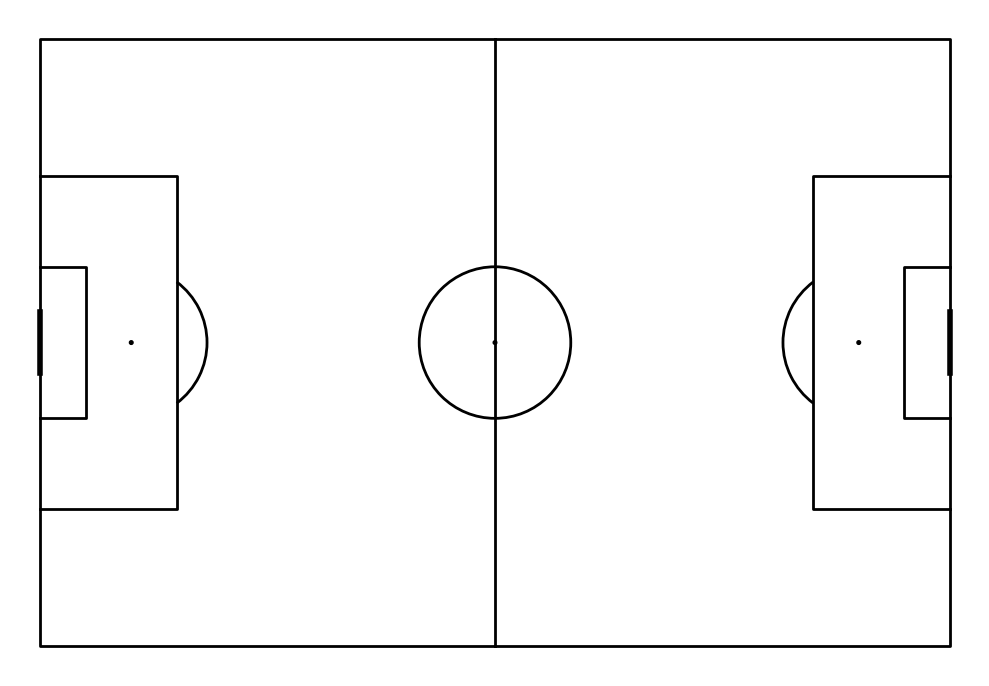

In [10]:
pitch = Pitch(line_color='black')
fig, ax = pitch.draw(figsize=(10,7))